In [1]:
import os
from copy import deepcopy
from collections import OrderedDict
from time import perf_counter

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch

from EqLearner import EqLearner1D
from func_libraries import Poly_Deriv_Library
from sparse_regress_algs import SparseRegressAlg, RFE, Cross_Val_RFE, Cross_Val_RFE_V2, SSR, RFESparseRegression
from data_sampling import Rand_Col_Sampler
from PinnSrPlusPlusComparisonSettings import DefaultEQsModelParameters, OptimizedEQsModelParameters 
from data_loaders import PDELearningMatDataVerB, PDELearningMatData
import Networks

from PartialDerivFunctions import Nth_temporal_prtls

from OneDimSols import OneDimSols

In [2]:
# # KdV
# jobId = 20922
# arrayId = 23
# dflag = 13
# ver = 2

# # Allen Cahn
# jobId = 20645
# arrayId = 10
# dflag = 3
# ver = 1

# # Allen Cahn
# jobId = 20712
# arrayId = 10
# dflag = 3
# ver = 3

# # Kln-Grd
# jobId = 20801
# arrayId = 3
# dflag = 14
# ver = 2

# # Heat EQ
# jobId = 20606
# arrayId = 5
# dflag = 9
# ver = 1

# Burgres Exp EQ
jobId = 20411
arrayId = 33
dflag = 6
ver = 1

# # Burgres Exp EQ
# jobId = 200495
# arrayId = 12
# dflag = 8
# ver = 1


data_slct_type = "RandPointsData"
node = 'desktop'

In [3]:
jobID , jobVer = jobId, arrayId
dvc = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# dvc = torch.device('cpu')

# (Dname, nDpnts, nTrn, nCpnts, noise, data_seed, sptl_ord, tmp_order, polyDeg, 
#     numLyrsU, nPrLU, prd_stuff, four_stuff, rnd_wght_fct,
#     ADO_iters, Kfolds, ADO_alphas, 
#     min_epchs, max_epchs, lrn_rt, preAlpha, preGamma,
#     min_pst_epchs, max_pst_epchs, pst_alpha, pst_lrn_rt) = DefaultEQsModelParameters(dFlag=dflag, ver=ver, run=jobVer, data_type=data_slct_type, computer=node)

(Dname, nDpnts, nTrn, nCpnts, noise, data_seed, sptl_ord, tmp_order, polyDeg, 
    numLyrsU, nPrLU, prd_stuff, four_stuff, rnd_wght_fct,
    ADO_iters, Kfolds, ADO_alphas, 
    min_epchs, max_epchs, lrn_rt, preAlpha, preGamma,
    min_pst_epchs, max_pst_epchs, pst_alpha, pst_lrn_rt) = OptimizedEQsModelParameters(dFlag=dflag, ver=ver, run=jobVer, data_type=data_slct_type, computer=node)

# slvr = RFE(alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=5)
# slvr = Cross_Val_RFE(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=ADO_iters)
# slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
# slvr = SSR(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), percent_redux=0.70, criteria="coefficient_value", ADO_iters=ADO_iters, normalize=True)

In [4]:
DataFile = '../Testing_DataSets/'+Dname+'.mat'
data_set = (Dname + "_" + "N" + str(int(noise)) + "_" +
                "P" + str(nDpnts))

# saveName = 'ResultsForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
# sv_mdl_name = 'LrnrForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
# Optim Results Names
saveName = 'OptimalVer4ResultsForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
sv_mdl_name = 'OptimalVer4LrnrForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)

data = sio.loadmat(file_name=DataFile)
x = data['x'].flatten()
t = data['t'].flatten()
u = data['usol']

# n_x = x.shape[0]
# n_t = t.shape[0]

[X, T] = np.meshgrid(x, t)
if u.shape!=X.shape:
    u = u.T

pts = np.concatenate((X.reshape((-1,1),order='C'), T.reshape((-1,1),order='C')), axis=1)
U = u.reshape((-1,1), order='C')

(d_seed, Nsp, Ns, subsample_prcntg,
            X_trn, U_trn,
            X_tst, U_tst,
            bounds) = PDELearningMatDataVerB(fname=DataFile, Sptldims=1, Ntrn=nDpnts, Ntst=nDpnts//4, noisePrcntg=noise,#, noisePrcntg=0.0,#  
                 seed=data_seed, to_float=True,)

# (d_seed, _, Ns, subsample_prcntg,
#             X_trn, U_trn,
#             X_tst, U_tst,
#             bounds) = PDELearningMatData(fname=DataFile, Sptldims=1, split=0.80, smpleprcnt=0.20, noisePrcntg=noise, 
#                  seed=data_seed, to_float=True, N_trn_pnts=nDpnts)

res_dict = {'jobID':jobID, 'jobVer':jobVer, 'node':node, 'subsample_prcntg':subsample_prcntg, 'noisePrcntg':noise, 'NpSeed':d_seed, 'Ns':Ns}

The entropy or np seed used for seeding the default rng routine is 81724882448365790789774097617785184203


C:\Users\urzua\AppData\Local\Temp\ipykernel_52012\3496785374.py:29: UserWarning: WARNING; Given float noisePrcntg value is either is greater than 1.0 and so to convert it to
a decimal value it will be divided by 100 as we are interpretting any value greater than 1.0
to be a percentage and thus to convert out of a percentage (i.e p%) divided by 100 and use 
that value (i.e p/100).
  bounds) = PDELearningMatDataVerB(fname=DataFile, Sptldims=1, Ntrn=nDpnts, Ntst=nDpnts//4, noisePrcntg=noise,#, noisePrcntg=0.0,#


In [5]:
libr = Poly_Deriv_Library(
        poly_degree=polyDeg,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=sptl_ord,
        sptl_dims=1,
        include_bias=False,
        include_deriv_interaction=True,
        multi_indices=None,
        device=dvc,
        data_type=torch.float32)

d_dict = {"Train_Inputs":X_trn, "Train_Targets":U_trn, "Test_Inputs":X_tst, "Test_Targets":U_tst}

col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=2, seed=None, 
                             bounds=bounds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)

In [6]:
DataFile

'../Testing_DataSets/Burgers_Exp.mat'

In [7]:
net = torch.nn.Sequential(
        torch.nn.Linear(in_features=2, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
).to(device=dvc, dtype=torch.float32)

# # for param in net.parameters():
# #     if param.ndim==2:
# #         torch.nn.init.xavier_normal_(param, gain=1.41)
# #     elif param.ndim==1:
# #         torch.nn.init.zeros_(param)

for name, param in net.named_parameters(): 
    if 'weight'in name:
        torch.nn.init.xavier_normal_(param.data, gain=1.41)
    # if 'bias' in name:
    #     torch.nn.init.zeros_(param.data)

In [8]:
# class TstFourEmbNetwork(torch.nn.Module):
#     def __init__(self, scale:float, inpt_dim:int, embd_dim:int, n_hidden_layers:int, nodes_per_layer:int, out_dim:int):
#         """
#         Input arguments for the class are as follows:

#             scale - positive float input that is the stand. dev
#                     of the normal distribution from which the 
#                     entries in the B matrix are randomly sampled
#                     from. Recommended that 1<=scale<=10.
#             inpt_dim - The number of dimensions that any input 
#                     to this model will have. Just the number of
#                     columns that an input tensor to this module
#                     will have. Needs to be a positive integer
#             embd_dim - The dimensionality of the embedding. If
#                     you want the embedding to have a dimension 
#                     d, the randomly sampled B matrix will have
#                     N rows and d//2 columns so that 
#                         Y = [cos(BX), sin(BX)]
#                     has d columns. Needs to be a positive integer. 
#         """
#         super().__init__()
#         # kernel = torch.distributions.normal.Normal(loc=0.0, scale=scale).sample((inpt_dim, embd_dim//2))
#         # self.register_buffer(name='kernel', tensor=kernel)
#         # self.register_parameter(name='kernel', 
#         #             param= torch.nn.Parameter(data=kernel, requires_grad=False))
#         self.inpt_dim = inpt_dim
#         self.scale = scale
#         # lyrs = [torch.nn.Linear(embd_dim, nodes_per_layer, bias=True)]
#         lyrs = [torch.nn.Linear(inpt_dim, nodes_per_layer, bias=True)]
#         torch.nn.init.xavier_normal_(lyrs[0].weight.data, gain=1.41)
#         lyrs.append(torch.nn.Tanh())
#         for _ in range(0, n_hidden_layers):
#             lyrs.append(torch.nn.Linear(nodes_per_layer, nodes_per_layer, bias=True))
#             torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)
#             lyrs.append(torch.nn.Tanh())
#         lyrs.append(torch.nn.Linear(nodes_per_layer, out_dim, bias=True))
#         torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)

#         self.network = torch.nn.Sequential(*lyrs)
    
#     def forward(self, x:torch.Tensor)->torch.Tensor:
#         """
#         The forward operation of the module. How to pass any 
#         given input tensor through the module. 
#         """
#         if self.inpt_dim != x.shape[-1]:
#             raise ValueError(f"Input X argument does not have the correct input size")
#         # y = torch.cat((torch.cos(torch.matmul(x, self.kernel)),torch.sin(torch.matmul(x, self.kernel)) ), dim=1)
#         y=x
#         return self.network(y)#*(x[:,0:1].pow(2) - 1)
    

class TstFourEmbNetwork(torch.nn.Module):
    def __init__(self, scale:float, inpt_dim:int, embd_dim:int, n_hidden_layers:int, nodes_per_layer:int, out_dim:int):
        """
        Input arguments for the class are as follows:

            scale - positive float input that is the stand. dev
                    of the normal distribution from which the 
                    entries in the B matrix are randomly sampled
                    from. Recommended that 1<=scale<=10.
            inpt_dim - The number of dimensions that any input 
                    to this model will have. Just the number of
                    columns that an input tensor to this module
                    will have. Needs to be a positive integer
            embd_dim - The dimensionality of the embedding. If
                    you want the embedding to have a dimension 
                    d, the randomly sampled B matrix will have
                    N rows and d//2 columns so that 
                        Y = [cos(BX), sin(BX)]
                    has d columns. Needs to be a positive integer. 
        """
        super().__init__()
        kernel = torch.distributions.normal.Normal(loc=0.0, scale=scale).sample((inpt_dim, embd_dim//2))
        self.register_buffer(name='kernel', tensor=kernel)
        # self.register_parameter(name='kernel', 
        #             param= torch.nn.Parameter(data=kernel, requires_grad=False))
        self.inpt_dim = inpt_dim
        self.scale = scale
        lyrs = [torch.nn.Linear(embd_dim, nodes_per_layer, bias=True)]
        # lyrs = [torch.nn.Linear(inpt_dim, nodes_per_layer, bias=True)]
        torch.nn.init.xavier_normal_(lyrs[0].weight.data, gain=1.41)
        lyrs.append(torch.nn.Tanh())
        for _ in range(0, n_hidden_layers):
            lyrs.append(torch.nn.Linear(nodes_per_layer, nodes_per_layer, bias=True))
            torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)
            lyrs.append(torch.nn.Tanh())
        lyrs.append(torch.nn.Linear(nodes_per_layer, out_dim, bias=True))
        torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)

        self.network = torch.nn.Sequential(*lyrs)
    
    def forward(self, x:torch.Tensor)->torch.Tensor:
        """
        The forward operation of the module. How to pass any 
        given input tensor through the module. 
        """
        if self.inpt_dim != x.shape[-1]:
            raise ValueError(f"Input X argument does not have the correct input size")
        y = torch.cat((torch.cos(torch.matmul(x, self.kernel)),torch.sin(torch.matmul(x, self.kernel)) ), dim=1)
        # y=x
        return self.network(y)*(x[:,0:1].pow(2) - 1)

net = TstFourEmbNetwork(scale=2.0, inpt_dim=2, embd_dim=48, n_hidden_layers=5, nodes_per_layer=96, out_dim=1).to(device=dvc, dtype=torch.float32)
    


# net = TstFourEmbNetwork(scale=2.0,
#         inpt_dim=2,
#         embd_dim=24,
#         n_hidden_layers=numLyrsU,
#         nodes_per_layer=96,
#         out_dim=1
#     ).to(device=dvc, dtype=torch.float32)

# # prd_stuff = {"period":(torch.pi/20,), "axis":(0,), "trainable":(False,)}
# prd_stuff = None
# four_stuff = None
# rnd_wght_fct = False

# dct = OrderedDict()
# if prd_stuff:
#     dct['Period_Embed'] = Networks.Periodic_Embedding(**prd_stuff)
#     # dct['Period_Embed'] = Networks.Periodic_EmbeddingVer2(**prd_stuff)
# if four_stuff:
#     dct['Fourier_Embed'] = Networks.Fourier_Embedding(**four_stuff)
# dct['InptLayer'] = Networks.DenseLayer(in_dim=2, out_dim=nPrLU, 
#                               weight_init_func=lambda z: torch.nn.init.xavier_normal_(z, gain=1.41),
#                              bias=True, 
#                             #  bias_init_func=lambda y: torch.nn.init.zeros_(y),
#                              bias_init_func=lambda y: torch.nn.init.uniform_(y, a=-(2)**0.5, b=2**0.5),
#                              rnd_wght_fact=rnd_wght_fct, mean=1.0, std=0.1)
# dct['ActFunc0'] = deepcopy(torch.nn.Tanh())
# for i in range(1, numLyrsU+1):
#     dct[f"HidnLay{i}"] = Networks.DenseLayer(in_dim=nPrLU, out_dim=nPrLU, 
#                               weight_init_func=lambda z: torch.nn.init.xavier_normal_(z, gain=1.41),
#                              bias=True, 
#                             #  bias_init_func=lambda y: torch.nn.init.zeros_(y),
#                              bias_init_func=lambda y: torch.nn.init.uniform_(y, a=-(nPrLU)**0.5, b=nPrLU**0.5),
#                              rnd_wght_fact=rnd_wght_fct, mean=1.0, std=0.1)
#     dct[f"ActFunc{i}"] = deepcopy(torch.nn.Tanh())
# dct['OutLayer'] = Networks.DenseLayer(in_dim=nPrLU, out_dim=1, 
#                               weight_init_func=lambda z: torch.nn.init.xavier_normal_(z, gain=1.41),
#                              bias=True, 
#                             #  bias_init_func=lambda y: torch.nn.init.zeros_(y),
#                              bias_init_func=lambda y: torch.nn.init.uniform_(y, a=-(nPrLU)**0.5, b=nPrLU**0.5),
#                              rnd_wght_fact=rnd_wght_fct, mean=1.0, std=0.1)
# net = torch.nn.Sequential(dct).to(device=dvc, dtype=torch.float32)


In [9]:
libr.fit(network=net, inpts=torch.rand(size=(2,2), device=dvc, dtype=torch.float32))
lib_names = libr.get_library_names(net_out_func_names=['u'])

init_lmbda = torch.zeros(size=(len(lib_names),1), device=dvc,)
lrnr = EqLearner1D(net=net,
        Lmbda=init_lmbda.requires_grad_(True),
        lib_func=libr,
        sprs_slvr=slvr,
        data_dict=d_dict,
        tmprl_ords=[tmp_order],
        col_pnts_smplr=col_smplr,
        N_col_pnts=nCpnts,
        ntwk_out_names=["u"],
        device=dvc,
        data_type=torch.float32
)

In [10]:
run_time = 0
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="pre", alpha=preAlpha, gamma=preGamma, min_epochs=min_epchs, max_epochs=max_epchs, 
                        lrn_rt=lrn_rt, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
# lrnr.AdamsOptimTraining(mode="pre", alpha=0.0, gamma=0.0, min_epochs=min_epchs, max_epochs=max_epchs, 
#                         lrn_rt=lrn_rt, lp_ord=1.0, outputFreq=200,
#                         betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 9.73047e+02 | 6.82960e+03 | 0.0000e+00
            | Test Data  | 4.74953e+02 | 7.36340e+05 | 
Epoch   200 | Train Data | 2.87905e+01 | 5.01589e+02 | 1.3532e-02
            | Test Data  | 2.66287e+01 | 5.01975e+02 | 
Epoch   400 | Train Data | 1.60977e+01 | 2.70719e+02 | 1.1469e-02
            | Test Data  | 1.47680e+01 | 2.69814e+02 | 
Epoch   600 | Train Data | 1.10269e+01 | 1.77065e+02 | 1.3422e-02
            | Test Data  | 1.05159e+01 | 1.75666e+02 | 
Epoch   800 | Train Data | 8.17964e+00 | 1.27551e+02 | 2.2031e-02
            | Test Data  | 8.16138e+00 | 1.26547e+02 | 
Epoch  1000 | Train Data | 6.34229e+00 | 9.72156e+01 | 3.1692e-02
            | Test Data  | 6.56733e+00 | 9.69420e+01 | 
Epoch  1200 | Train Data | 5.07858e+00 | 7.68939e+01 | 4.0704e-02
            | Tes

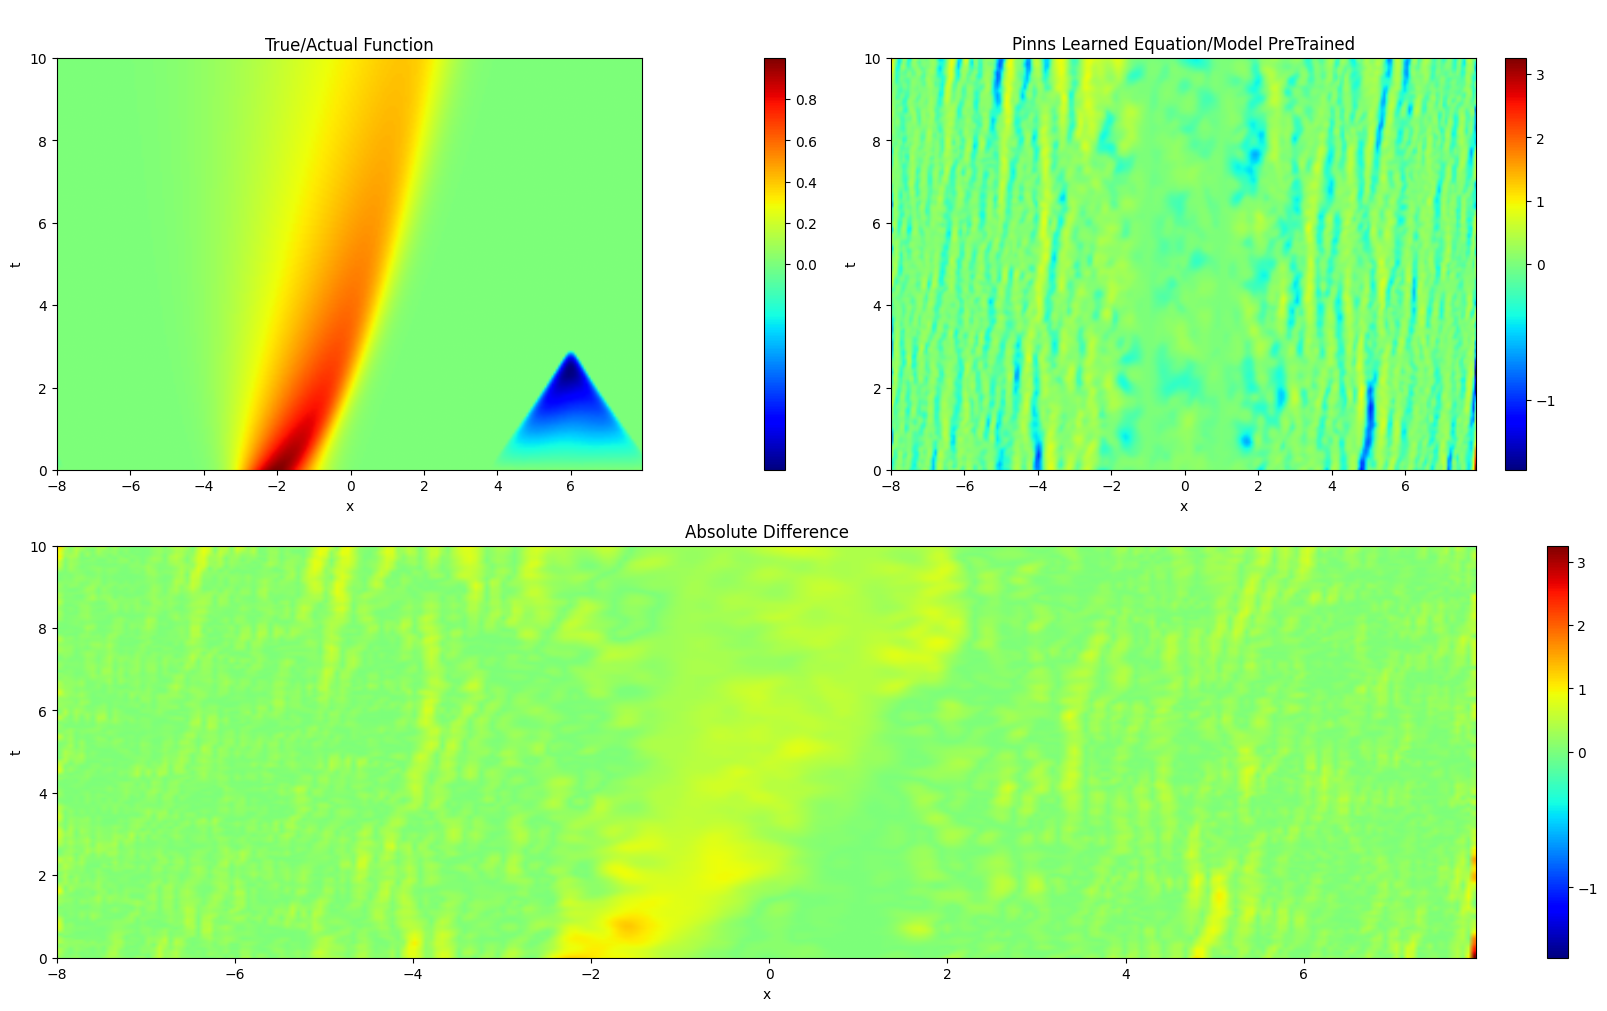

In [11]:
lrnr.ContourLikeComparisonPlot(dataset_name=data_set, pts=pts, values=U, fig_title=' ', state="PreTrained", show_fig=False, save_fig=False, save_title=saveName+'PreTrained', dif=False,exact=False, learned=False)

In [12]:
data = sio.loadmat(file_name=DataFile)
x = data['x'].flatten()
t = data['t'].flatten()
u = data['usol']

noisePrcntg = noise if noise<1.0 else noise/100

rng = np.random.default_rng(seed=data_seed)
sol = u + rng.normal(loc=0, scale=noisePrcntg*np.std(u) , size=u.shape)

n_x = x.shape[0]
n_t = t.shape[0]

[X, T] = np.meshgrid(x, t)
if sol.shape!=X.shape:
    sol = sol.T
    u = u.T

pts = np.concatenate((X.reshape((-1,1),order='C'), T.reshape((-1,1),order='C')), axis=1)
ani_vals = sol.reshape((-1,1), order='C')
cln_vals = u.reshape((-1,1), order='C')

In [13]:
print(ani_vals.std())
print((ani_vals-cln_vals).std())
print(cln_vals.std()*(noise/100))
print(U_trn.std())
print(U_tst.std())
print(np.vstack((U_trn,U_tst)).std())

0.25619584324323835
0.18133901030257513
0.18127206183944264
0.25595900560028834
0.2508559675702087
0.2549480921658108


In [14]:
xtr_nsy_dta = np.stack([cln_vals + rng.normal(loc=0.0, scale=cln_vals.std()*(noise/100), size=cln_vals.shape) for _ in range(250)], axis=0)
# rmvd_ns_dta = np.stack([ani_vals - rng.normal(loc=0.0, scale=cln_vals.std()*(noise/100), size=cln_vals.shape) for _ in range(1)], axis=0)

In [15]:
tmp_nsls_dta = []
for _ in range(1_000):
    gaus_vals = rng.normal(loc=0.0, scale=cln_vals.std()*(noise/100), size=cln_vals.shape)
    tmp_nsls_dta.append(np.where(ani_vals>cln_vals, ani_vals-np.abs(gaus_vals), ani_vals+np.abs(gaus_vals)))
rmvd_ns_dta = np.stack(tmp_nsls_dta, axis=0)

In [16]:
Q_clnd_data = xtr_nsy_dta.mean(axis=0)
Q_rmvd_data = rmvd_ns_dta.mean(axis=0)

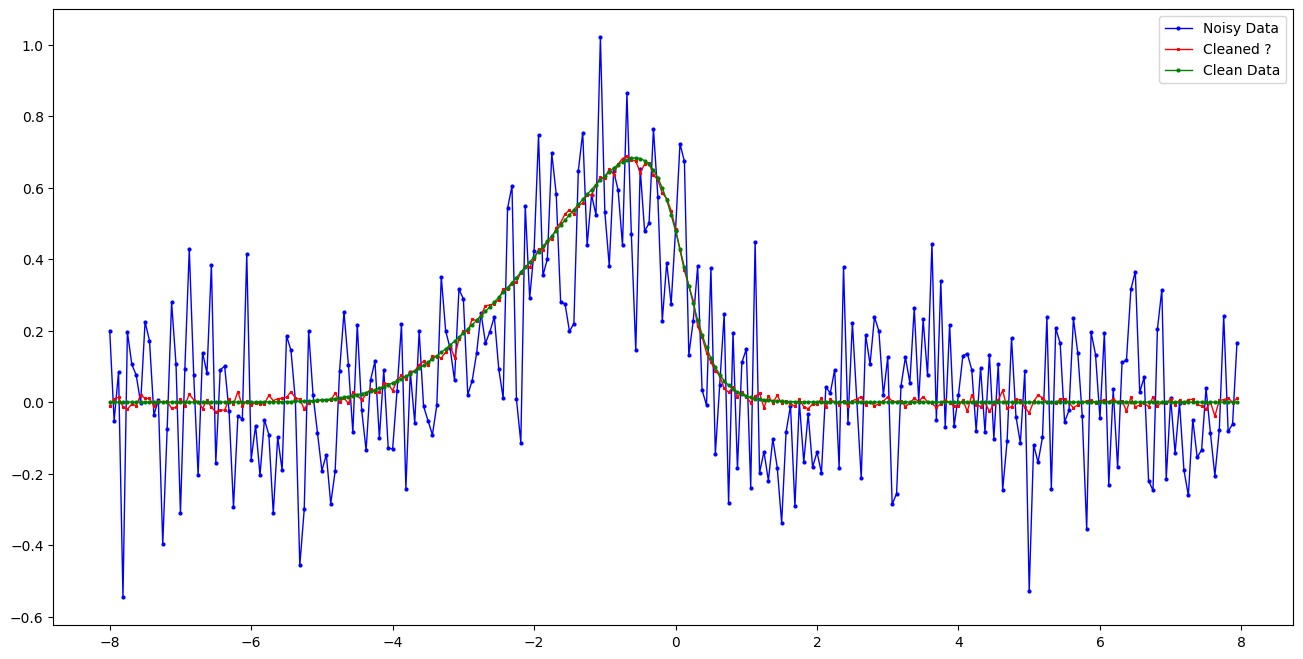

In [17]:
k=50
plt.figure(figsize=(16,8))
plt.plot(x, ani_vals[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy Data')
plt.plot(x, Q_clnd_data[k*n_x:(k+1)*n_x:, :], color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Cleaned ?')
# plt.plot(x, Q_rmvd_data[k*n_x:(k+1)*n_x:, :], color='black', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Rmvd ?')
plt.plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean Data')

plt.legend()

In [18]:
# Something to make sure that we have the prediction and the exact values on the cpu and in numpy arrays for ploting
if isinstance(ani_vals, torch.Tensor):vals = ani_vals.cpu().detach().numpy()
elif isinstance(ani_vals, np.ndarray):vals = np.copy(ani_vals)
else: raise TypeError(f"The values function argument needs to be either a torch.Tensor or numpy.ndarray object not a {type(ani_vals).__name__} object as was given!")
if isinstance(cln_vals, torch.Tensor):vals_cln = cln_vals.cpu().detach().numpy()
elif isinstance(cln_vals, np.ndarray):vals_cln = np.copy(cln_vals)
# N by 2 array/tensors these need to be. 
if isinstance(pts, torch.Tensor):X = pts.cpu().detach().numpy()
elif isinstance(pts, np.ndarray): X = np.copy(pts)
else:raise TypeError(f"The pts function argument needs to be either a torch.Tensor or numpy.ndarray object not a {type(pts).__name__} object as was given!")
        
# sv_dir = os.path.join('PosterAnimatedPlots', data_set)
# os.makedirs(name=sv_dir, exist_ok=True)
    
t = np.unique(X[:, 1])
t.sort()
rnd = int(np.log10(np.min(t[1:]-t[:-1]))) + 3
y_max = np.ceil(vals.max())
y_min = np.floor(vals.min())
x_max, x_min = np.ceil(pts[:, 0].max()), np.floor(pts[:,0].min())
mins = [x_min, y_min]
maxs = [x_max, y_max]
        


In [19]:
maxs

[np.float64(8.0), np.float64(2.0)]

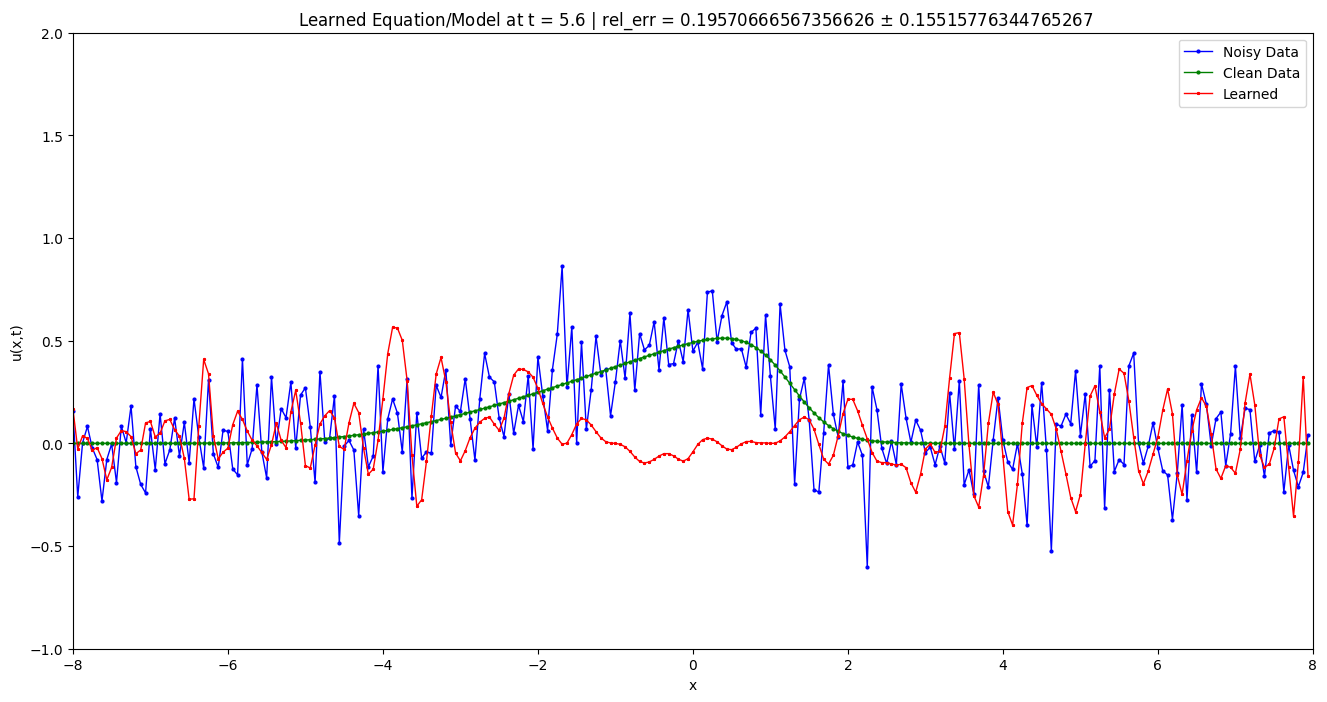

In [20]:
plot_fig, ax = plt.subplots()
plot_fig.set_size_inches(w=16, h=8)

k = rng.choice(a=n_t, size=(1,)).item()
# k = 0
n_t = t.shape[0]
n_x = int(pts.shape[0]/n_t)
x = pts[k*n_x:(k+1)*n_x,0:1]
# x.sort()
lrn = lrnr.net(torch.from_numpy(pts[k*n_x:(k+1)*n_x,:]).to(device=lrnr.device, dtype=lrnr.data_type, non_blocking=True)).cpu().detach().numpy()
x_min, y_min = mins
x_max, y_max = maxs

rel_errors = np.where(cln_vals[k*n_x:(k+1)*n_x:, :]==0, np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :]), np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :])/np.abs( cln_vals[k*n_x:(k+1)*n_x:, :]))
rel_errors = np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :])

ax.clear()
ax.plot(x, ani_vals[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy Data')
ax.plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean Data')
ax.plot(x, lrn, color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Learned')
ax.set_xlabel('x')
ax.set_xlim(left=x_min, right=x_max)
ax.set_ylabel('u(x,t)')
ax.set_ylim(bottom=y_min, top=y_max)
ax.set_title(r' Learned Equation/Model at t = {} | rel_err = {} $\pm$ {}'.format(t[k].round(4), rel_errors.mean(), rel_errors.std()))
ax.legend()

In [21]:
# print(x[[0, 24, 51, 77,128, 155, 156, 179],0])
# print(cln_vals[[0, 24, 51, 77,128, 155, 156, 179],0])
# print(lrn[[0, 24, 51, 77,128, 155, 156, 179],0])
# print(rel_errors[np.nonzero(rel_errors>=0.99999)])
# print(np.nonzero(rel_errors>=0.99999)[0])
# cln_vals[np.nonzero(rel_errors>=0.99999)[0],0]

In [22]:
# tst_solver = RFE(alpha=torch.zeros((1,), device=dvc), normalize=True, annealing_factor=1)
tst_solver = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria='coefficient_value', selection="individual", best=True, ADO_iters=ADO_iters,thrshld_val=0.0)
# tst_solver = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria='coefficient_value', selection="individual", best=True, ADO_iters=ADO_iters,thrshld_val=0.0)
# tst_solver = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_f actor=2, criteria='model_residual', selection="individual", best=True, ADO_iters=ADO_iters,thrshld_val=0.0)
# tst_solver = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria='model_residual', selection="individual", best=True, ADO_iters=ADO_iters,thrshld_val=0.0)

colpts = torch.from_numpy(col_smplr.sample(nCpnts)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
tprtls = Nth_temporal_prtls(values=net(colpts), pts=colpts, orders=lrnr.tmprl_ords).detach()
lib_evals = libr.Calc(network=net, inpts=colpts).detach()

In [23]:
print(lib_names)

['u', 'u_x0', 'u_x0x0', '(u)^2', '(u)(u_x0)', '(u)(u_x0x0)', '(u_x0)^2', '(u_x0)(u_x0x0)', '(u_x0x0)^2']


In [24]:
nzs_ids = lrnr.lmbda.data.nonzero(as_tuple=True)[0]
iter_lmbda = torch.zeros_like(lrnr.lmbda.data)
iter_lmbda[nzs_ids] = tst_solver.solve(A=lib_evals[:, nzs_ids], b=tprtls)
iter_lmbda

tensor([[ 6.7468e-02],
        [-8.1077e-02],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 6.4130e-03],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [-8.9110e-05],
        [ 2.0285e-06]], device='cuda:0')

In [25]:
RFESparseRegression(A=lib_evals, b=tprtls, annealing_factor=2.0, best=True)

(tensor([[ 5.5073e-02],
         [-8.0909e-02],
         [ 0.0000e+00],
         [ 8.6428e-02],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 4.1536e-04],
         [-9.2099e-05],
         [ 0.0000e+00]], device='cuda:0'),
 tensor([[ 0.0000],
         [-0.0810],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000]], device='cuda:0'))

In [26]:
# lrnr.lmbda.data = torch.zeros_like(lrnr.lmbda.data)
# lrnr.lmbda.data[[2,4]] = tst_solver.solve(A=lib_evals[:, [2,4]], b=tprtls)

In [27]:
strt = perf_counter()
lrnr.ADO_Training(iters=ADO_iters, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=True, Save_File_Name=None, Early_RFE_Term=True, p=0.5)
# lrnr.ADO_Training(iters=ADO_iters, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=False, Save_File_Name=None, Early_RFE_Term=True, p=0.5, train_alphas=ADO_alphas/ADO_alphas)
run_time += (perf_counter() - strt)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
u_t = 7.07028270e-01*u + 4.08689000e-03*u_x0x0 + -6.30497870e-01*(u)^3 + -3.27413400e-02*(u)^2(u_x0) + -5.70040000e-03*(u)^2(u_x0x0) + -1.03258200e-02*(u)(u_x0)^2 + -6.52760000e-04*(u)(u_x0)(u_x0x0) + -6.21700000e-05*(u)(u_x0x0)^2 + -6.56300000e-05*(u_x0)^2(u_x0x0) + -3.27000000e-06*(u_x0)(u_x0x0)^2 + -4.20000000e-07*(u_x0x0)^3
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.27040e-01 | 3.36332e-01 | 1.3912e+00
            | Test Data  | 1.30036e-01 | 4.84341e+02 | 
Epoch   100 | Train Data | 1.91820e-01 | 2.92812e-01 | 1.3912e+00
            | Test Data  | 1.91577e-01 | 2.92692e-01 | 
Epoch   200 | Train Data | 1.64562e-01 | 1.89336e-01 | 1.3914e+00
            | Test Data  | 1.63716e-01 | 1.90248e-01 | 
Epoch   300 | Train Data | 1.56582e-01 | 1.3079

In [28]:
lrnr._ADO_alphas[-1]

np.float64(0.8166800737380981)

In [30]:
lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
u_t = 7.21804080e-01*u + 2.25121000e-03*u_x0x0 + -6.78177120e-01*(u)^3 


In [31]:
lrnr.AdamsOptimTraining(mode='ado', alpha=1.0, gamma=0.0, max_epochs=lrnr._AdamsPreTrnEpochs, lrn_rt=0.001, lp_ord=1, outputFreq=100);

Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.02531e-01 | 2.35628e-03 | 1.4022e+00
            | Test Data  | 6.49979e-01 | 1.21217e+01 | 
Epoch   100 | Train Data | 1.13472e-01 | 1.65858e-02 | 1.3966e+00
            | Test Data  | 1.11143e-01 | 1.58520e-02 | 
Epoch   200 | Train Data | 1.06208e-01 | 5.81896e-03 | 1.3929e+00
            | Test Data  | 1.03926e-01 | 5.98115e-03 | 
Epoch   300 | Train Data | 1.04190e-01 | 3.30338e-03 | 1.3920e+00
            | Test Data  | 1.02396e-01 | 3.68139e-03 | 
Epoch   400 | Train Data | 1.03419e-01 | 2.34013e-03 | 1.3926e+00
            | Test Data  | 1.01960e-01 | 2.70562e-03 | 
Epoch   500 | Train Data | 1.03113e-01 | 1.90485e-03 | 1.3945e+00
            | Test Data  | 1.01803e-01 | 2.19777e-03 | 
Epoch   600 | Train Data | 1.02964e-01 | 1.67455e-03 | 1.3971e+00
            | Tes

In [32]:
lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
u_t = 7.32251820e-01*u + 2.35657000e-03*u_x0x0 + -6.73998060e-01*(u)^3 


In [33]:
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="post", alpha=1.0, gamma=0.0, min_epochs=min_pst_epchs, max_epochs=max_pst_epchs, 
                        lrn_rt=pst_lrn_rt, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Post-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.02838e-01 | 1.27570e-03 | 1.4086e+00
            | Test Data  | 2.64919e-01 | 1.24651e+00 | 
Epoch   200 | Train Data | 1.02978e-01 | 1.56151e-03 | 1.3985e+00
            | Test Data  | 1.01790e-01 | 1.74342e-03 | 
Finished Adams Post Training


In [34]:
lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
u_t = 7.31251840e-01*u + 3.35657000e-03*u_x0x0 + -6.74998100e-01*(u)^3 


In [684]:
res_dict['run_time'] =  run_time
err, errs, RHS_eq, = OneDimSols(dataset=Dname, lib=lib_names, lrnd_sol=lrnr.lmbda.data.cpu().numpy())
learned = lrnr.Learned_EQ(output=False, sup_zeros=True,)
print("The learned equation(s) was ...\n" + learned)
crctEQ = 'u_'+'t'*tmp_order +' = '  + RHS_eq
fig_title = 'Learned EQ - '+learned+'\n Correct EQ - '+crctEQ


The learned equation(s) was ...
u_t = 7.48797540e-01*u + 2.71939000e-03*u_x0x0 + -7.12490500e-01*(u)^3 


In [35]:
lrning_data = np.vstack((X_trn, X_tst))
lrning_trgts = np.vstack((U_trn, U_tst))
lrning_dt_preds = lrnr.net(torch.from_numpy(lrning_data).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

In [36]:
smpl_std = (lrning_trgts - lrning_dt_preds).std()
print(smpl_std)

0.5104441335391579


In [37]:
# nsy_data_preds = [lrning_trgts]
# for _ in range(100):
#    nsy_data_preds.append(lrning_dt_preds + rng.normal(loc=0.0, scale=smpl_std, size=lrning_dt_preds.shape))

full_preds = lrnr.net(torch.from_numpy(pts).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()
nsy_data_preds = [ani_vals]
for _ in range(50):
   nsy_data_preds.append(full_preds + rng.normal(loc=0.0, scale=smpl_std, size=full_preds.shape))

In [38]:
nsy_rmvd_data = np.stack(nsy_data_preds, axis=0).mean(axis=0)

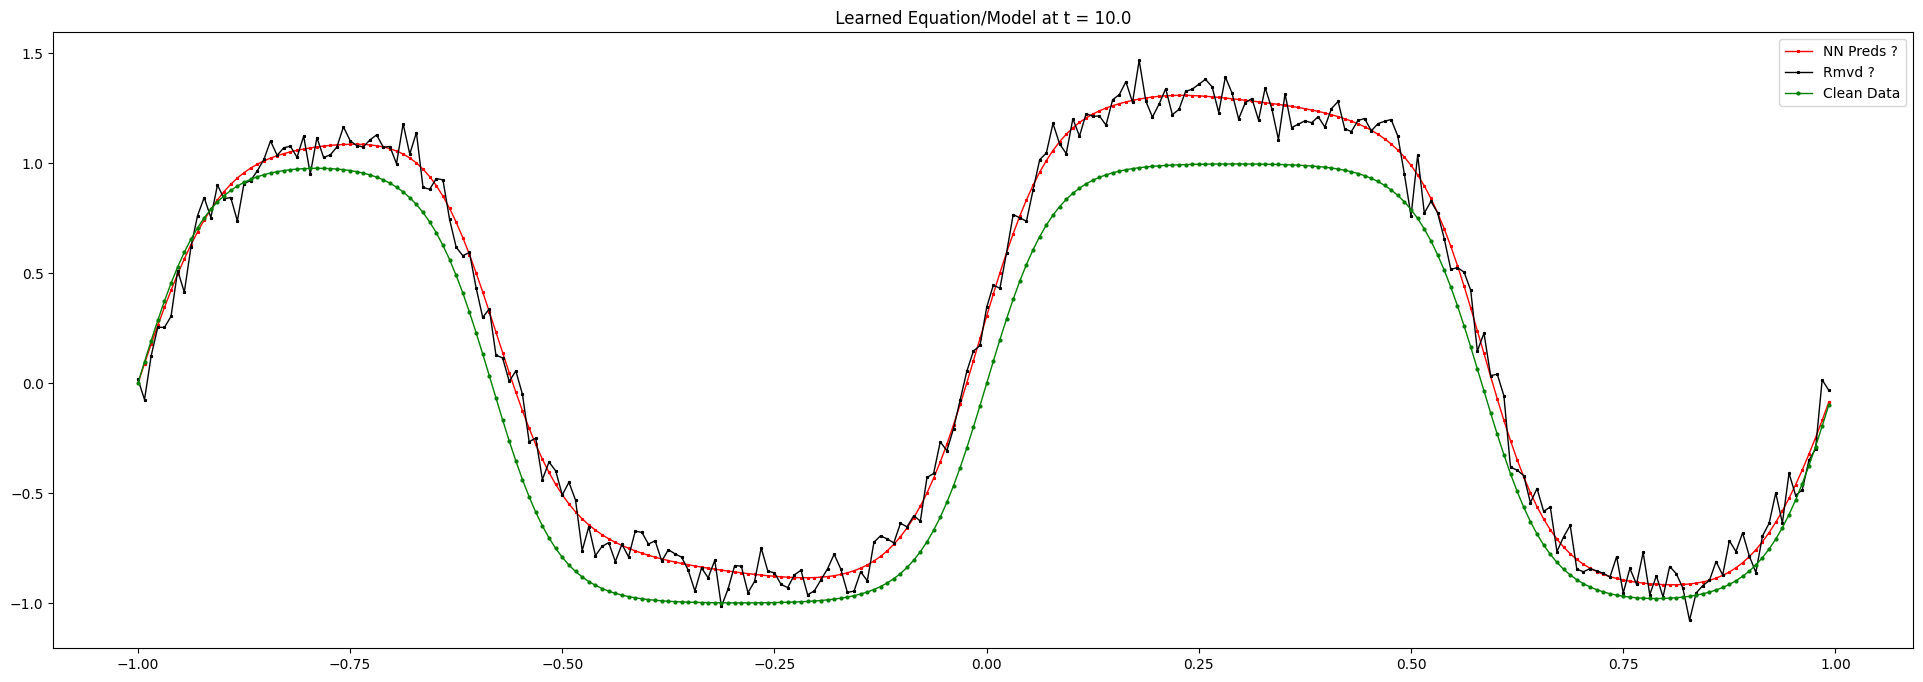

In [45]:
k = 200
plt.figure(figsize=(24,8))
# plt.plot(x, ani_vals[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy Data')
plt.plot(x, full_preds[k*n_x:(k+1)*n_x:, :], color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='NN Preds ?')
plt.plot(x, nsy_rmvd_data[k*n_x:(k+1)*n_x:, :], color='black', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Rmvd ?')
plt.plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean Data')
plt.legend()
plt.title(r' Learned Equation/Model at t = {} '.format(t[k].round(4)));

In [396]:
from scipy.stats.qmc import Sobol, LatinHypercube, Halton, scale
from torch.optim import Adam
from PartialDerivFunctions import sptl_partials, Nth_temporal_prtl

In [513]:
smplr = Sobol(d=2, scramble=True, optimization='random-cd', )
# smplr = Halton(d=2, scramble=True, optimization='random-cd',)
# smplr = LatinHypercube(d=2, scramble=True, optimization='random-cd', strength=1)

In [514]:
pwr = np.ceil(np.log2(nDpnts)).astype(int).item()
bounds[0,1] = 1.0

In [436]:
trn_ins = torch.from_numpy(scale(sample=smplr.random_base2(pwr), l_bounds=bounds[:,0], u_bounds=bounds[:,1], )).to(device=dvc, dtype=torch.float32)
trn_trgts = net(trn_ins).detach()

In [515]:
class TstFourEmbNetwork(torch.nn.Module):
    def __init__(self, scale:float, inpt_dim:int, embd_dim:int, n_hidden_layers:int, nodes_per_layer:int, out_dim:int):
        """
        Input arguments for the class are as follows:

            scale - positive float input that is the stand. dev
                    of the normal distribution from which the 
                    entries in the B matrix are randomly sampled
                    from. Recommended that 1<=scale<=10.
            inpt_dim - The number of dimensions that any input 
                    to this model will have. Just the number of
                    columns that an input tensor to this module
                    will have. Needs to be a positive integer
            embd_dim - The dimensionality of the embedding. If
                    you want the embedding to have a dimension 
                    d, the randomly sampled B matrix will have
                    N rows and d//2 columns so that 
                        Y = [cos(BX), sin(BX)]
                    has d columns. Needs to be a positive integer. 
        """
        super().__init__()
        kernel = torch.distributions.normal.Normal(loc=0.0, scale=scale).sample((inpt_dim, embd_dim//2))
        self.register_buffer(name='kernel', tensor=kernel)
        # self.register_parameter(name='kernel', 
        #             param= torch.nn.Parameter(data=kernel, requires_grad=False))
        self.inpt_dim = inpt_dim
        self.scale = scale
        lyrs = [torch.nn.Linear(embd_dim, nodes_per_layer, bias=True)]
        # lyrs = [torch.nn.Linear(inpt_dim, nodes_per_layer, bias=True)]
        torch.nn.init.xavier_normal_(lyrs[0].weight.data, gain=1.41)
        lyrs.append(torch.nn.Tanh())
        for _ in range(0, n_hidden_layers):
            lyrs.append(torch.nn.Linear(nodes_per_layer, nodes_per_layer, bias=True))
            torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)
            lyrs.append(torch.nn.Tanh())
        lyrs.append(torch.nn.Linear(nodes_per_layer, out_dim, bias=True))
        torch.nn.init.xavier_normal_(lyrs[-1].weight.data, gain=1.41)

        self.network = torch.nn.Sequential(*lyrs)
    
    def forward(self, x:torch.Tensor)->torch.Tensor:
        """
        The forward operation of the module. How to pass any 
        given input tensor through the module. 
        """
        if self.inpt_dim != x.shape[-1]:
            raise ValueError(f"Input X argument does not have the correct input size")
        y = torch.cat((torch.cos(torch.matmul(x, self.kernel)),torch.sin(torch.matmul(x, self.kernel)) ), dim=1)
        # y=x
        return self.network(y)*(x[:,0:1].pow(2) - 1)

Fr_bnd_mlp = TstFourEmbNetwork(scale=2.0, inpt_dim=2, embd_dim=24, n_hidden_layers=5, nodes_per_layer=nPrLU, out_dim=1).to(device=dvc, dtype=torch.float32)

In [438]:
coef1 = torch.tensor(init_lmbda[0,0].item(), device=dvc, dtype=torch.float32, requires_grad=True,)
coef2 = torch.tensor(init_lmbda[2,0].item(), device=dvc, dtype=torch.float32, requires_grad=True,)
coef3 = torch.tensor(init_lmbda[9,0].item(), device=dvc, dtype=torch.float32, requires_grad=True,)

In [516]:
print(f"coef1={coef1} | coef2={coef2} | coef3={coef3} |")

coef1=0.9520089626312256 | coef2=0.002801605500280857 | coef3=-0.9511867761611938 |


In [517]:
optim = Adam(params=Fr_bnd_mlp.parameters(), lr=0.001, betas=(0.9, 0.999), )
# optim.param_groups[0]['params'].append(coef1)
# optim.param_groups[0]['params'].append(coef2)
# optim.param_groups[0]['params'].append(coef3)
schdlr = torch.optim.lr_scheduler.ExponentialLR(optimizer=optim, gamma=0.9, last_epoch=-1, ) 

In [518]:
trch_bnds = torch.from_numpy(bounds.T).to(device=dvc, dtype=torch.float32)

In [519]:
max_epochs = 5_000
outputFreq = 200
alpha = 1.0
tot_loss = []
data_loss = []
pde_loss = []

In [520]:
# colpnts = (torch.rand(size=(nCpnts, 2), device=dvc, dtype=torch.float32) *(trch_bnds[1] - trch_bnds[0]) + trch_bnds[0]).requires_grad_(True)
for i in range(max_epochs):
    Fr_bnd_mlp.train(True)
    
    colpnts = (torch.rand(size=(nCpnts, 2), device=dvc, dtype=torch.float32) *(trch_bnds[1] - trch_bnds[0]) + trch_bnds[0]).requires_grad_(True)
    colpnts.grad = None
        
    optim.zero_grad(set_to_none=True)
    Fr_bnd_mlp.train(True)

    dataL = torch.mean((Fr_bnd_mlp(trn_ins) - trn_trgts)**2)
    u = Fr_bnd_mlp(colpnts)
    u_t = Nth_temporal_prtl(values=u, pts=colpnts, order_n=1)
    u_xx = sptl_partials(values=u, pts=colpnts, order=2)[:,-1:]

    
    pdeL = torch.mean((u_t - coef1*u - coef2*u_xx - coef3*u.pow(3))**2)
    loss = dataL + alpha*pdeL
    loss.backward()

    tot_loss.append(loss.detach())
    data_loss.append(dataL.detach())
    pde_loss.append(pdeL.detach())

    optim.step()
    
    # Fr_bnd_mlp.eval()
    # tst_dataL = torch.mean((Fr_bnd_mlp(test_inputs) - test_targets)**2, dim=0).detach_()
    # tst_col_preds = Fr_bnd_mlp(test_inputs)
    # tst_t_prtls = Nth_temporal_prtls(values=tst_col_preds, pts=test_inputs, orders=self.tmprl_ords).detach_()
    # tst_lib_evals = self.lib_func.Calc(network=Fr_bnd_mlp, inpts=test_inputs)
    # tst_pdeL = torch.mean((tst_t_prtls - tst_lib_evals@self.lmbda)**2, dim=0,).detach_()
    # ts_loss = torch.sum(tst_dataL + alpha*tst_pdeL).detach_()
    # tst_loss.append( ts_loss.detach() )
    # tst_data_loss.append( tst_dataL.detach() )
    # tst_pde_loss.append( tst_pdeL.detach() )

    # if i%outputFreq==0 and i>0:
    if i%outputFreq==0:
        print(f"Epoch {i:5d} | Train Data | {dataL.sum().item():.5e} | {pdeL.sum().item():.5e} ")
        # print(f"Epoch {i:5d} | Train Data | {dataL.sum().item():.5e} | {pdeL.sum().item():.5e} | {lp_lss.sum().item():.4e}")
        # print(f"            | Test Data  | {tst_dataL.sum().item():.5e} | {tst_pdeL.sum().item():.5e} | ")
    if (i+1)%800==0:
        schdlr.step()

Epoch     0 | Train Data | 9.23976e-01 | 1.36789e+01 
Epoch   200 | Train Data | 3.38491e-01 | 3.50357e-02 
Epoch   400 | Train Data | 2.71771e-01 | 2.97544e-02 
Epoch   600 | Train Data | 2.01037e-01 | 2.61497e-02 
Epoch   800 | Train Data | 1.57678e-01 | 2.49170e-02 
Epoch  1000 | Train Data | 1.35665e-01 | 2.44347e-02 
Epoch  1200 | Train Data | 1.19555e-01 | 2.20839e-02 
Epoch  1400 | Train Data | 1.07776e-01 | 2.02200e-02 
Epoch  1600 | Train Data | 9.95468e-02 | 1.78508e-02 
Epoch  1800 | Train Data | 9.37943e-02 | 1.63716e-02 
Epoch  2000 | Train Data | 8.82918e-02 | 1.50232e-02 
Epoch  2200 | Train Data | 8.22465e-02 | 1.38485e-02 
Epoch  2400 | Train Data | 7.50750e-02 | 1.32968e-02 
Epoch  2600 | Train Data | 6.71587e-02 | 1.29272e-02 
Epoch  2800 | Train Data | 5.80976e-02 | 1.32058e-02 
Epoch  3000 | Train Data | 4.86252e-02 | 1.31864e-02 
Epoch  3200 | Train Data | 3.98778e-02 | 1.40499e-02 
Epoch  3400 | Train Data | 3.22930e-02 | 1.30411e-02 
Epoch  3600 | Train Data | 2

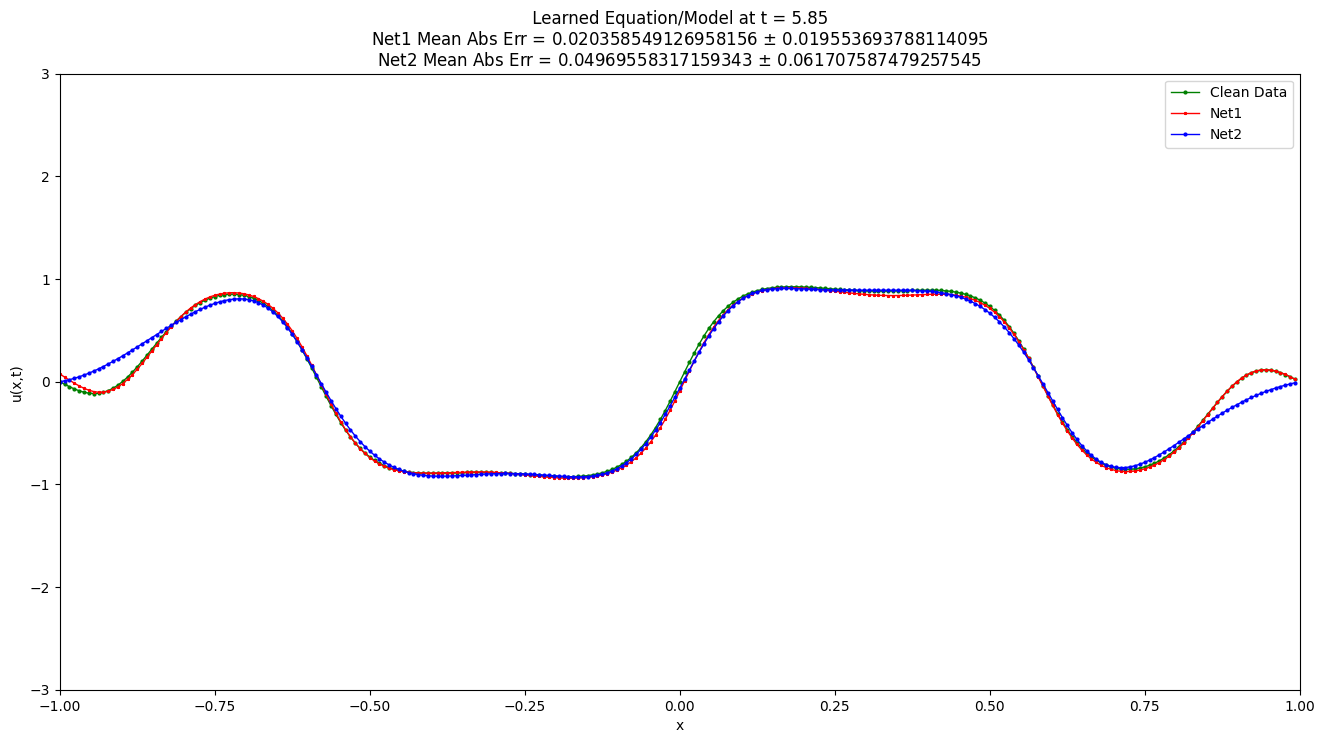

In [521]:
plot_fig, ax = plt.subplots()
plot_fig.set_size_inches(w=16, h=8)

k = rng.choice(a=n_t, size=(1,)).item()
# k = 0
# k=200
n_t = t.shape[0]
n_x = int(pts.shape[0]/n_t)
x = pts[k*n_x:(k+1)*n_x,0:1]
# x.sort()
lrn = lrnr.net(torch.from_numpy(pts[k*n_x:(k+1)*n_x,:]).to(device=lrnr.device, dtype=lrnr.data_type, non_blocking=True)).cpu().detach().numpy()
lrn2 = Fr_bnd_mlp(torch.from_numpy(pts[k*n_x:(k+1)*n_x,:]).to(device=lrnr.device, dtype=lrnr.data_type, non_blocking=True)).cpu().detach().numpy()
x_min, y_min = mins
x_max, y_max = maxs

# rel_errors = np.where(cln_vals[k*n_x:(k+1)*n_x:, :]==0, np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :]), np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :])/np.abs( cln_vals[k*n_x:(k+1)*n_x:, :]))
rel_errors1 = np.abs( lrn- cln_vals[k*n_x:(k+1)*n_x:, :])
rel_errors2 = np.abs( lrn2- cln_vals[k*n_x:(k+1)*n_x:, :])

ax.clear()
ax.plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean Data')
ax.plot(x, lrn, color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Net1')
ax.plot(x, lrn2, color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Net2')
ax.set_xlabel('x')
ax.set_xlim(left=x_min, right=x_max)
ax.set_ylabel('u(x,t)')
ax.set_ylim(bottom=y_min, top=y_max)
ax.set_title(r' Learned Equation/Model at t = {} '.format(t[k].round(4), ) +"\n" +r'Net1 Mean Abs Err = {} $\pm$ {}'.format(rel_errors1.mean(), rel_errors1.std()) + "\n" +r'Net2 Mean Abs Err = {} $\pm$ {}'.format(rel_errors2.mean(), rel_errors2.std()))
ax.legend()

In [511]:
print(f"coef1={coef1} | coef2={coef2} | coef3={coef3} |")

coef1=0.9520089626312256 | coef2=0.002801605500280857 | coef3=-0.9511867761611938 |


In [512]:
coefs_after = torch.linalg.lstsq(torch.concat((u, u_xx, u.pow(3)), dim=1), u_t, )[0]
coefs_after

tensor([[ 0.8658],
        [ 0.0026],
        [-0.8456]], device='cuda:0', grad_fn=<LinalgLstsqBackward0>)

In [494]:
coef1.data = coefs_after[0,0]
coef2.data = coefs_after[1,0]
coef3.data = coefs_after[2,0]

tensor(-0.9455, device='cuda:0')

In [ ]:
# lrnr.WriteResults(data_set_name=data_set, file_name=data_set+"OptimalVer4", precision=5, true_eq=crctEQ, errors=[err, errs], act_func='Tanh()', **res_dict)
# lrnr.TrainingLossPlots(dataset_name=data_set, file_name=saveName, plot_title=fig_title,)
# lrnr.ContourLikeComparisonPlot(dataset_name=data_set, pts=pts, values=U, fig_title=fig_title, state="PostTrained", show_fig=False, save_fig=True, save_title=saveName+'PostTrained', dif=False, exact=False, learned=False)
# lrnr.Loss_Score_Complexity_Plot(dataset_name=data_set, save_dir_name=saveName, save_figs=True)
# # lrnr.AnimatedPlot(dataset_name=data_set, spdx=2.0, pts=pts, values=U, 
# #                      ani_title=saveName+'PostTrained', fig_title=fig_title, state='PostTrained')
# lrnr.FVU_Plot(dataset_name=data_set, file_name=saveName, save_fig=True)
# lrnr.Save_Model(data_set=data_set, fname=sv_mdl_name)

In [ ]:
folder_loc = "Saved_Models/"+data_set
path = folder_loc +'/'+sv_mdl_name+'.tar'

# state = torch.load(f=path, weights_only=False)
# lrnr.net.load_state_dict(state['net_state_dict'])
# lrnr.lmbda = torch.from_numpy(state['lambda']).to(device=lrnr.device, dtype=lrnr.data_type).requires_grad_(True)

lrnr.Load_Model(folder_loc=folder_loc, fname=sv_mdl_name)
lrnr.lmbda.data = torch.from_numpy(lrnr._ADO_lambdas[-1]).to(device=lrnr.device, dtype=lrnr.data_type)

prd_stuff = {"period":(torch.pi/20,), "Ns":(1,), "axis":(0,), "trainable":(False,)}
four_stuff = None
rnd_wght_fct = True
net2 = Networks.MLP(in_dim=4, num_layers=numLyrsU, hid_dim=nPrLU,out_dim=1,
                      activ_func=torch.nn.Tanh(),
                      prd_stuff=prd_stuff, four_stuff=four_stuff,
                      rnd_wght_fct=rnd_wght_fct).to(device=dvc)
lrnr.net = net2

In [ ]:
run_time = 0
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="post", alpha=pst_alpha, gamma=0.0, min_epochs=1000, max_epochs=max_pst_epchs, 
                        lrn_rt=pst_lrn_rt, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)